In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df=pd.read_excel(r"C:\Users\MT-Team\Desktop\Employee Analysis\Employee Sample Data - A.xlsx")

In [4]:
data=pd.DataFrame(df)

In [5]:
print(data)

       EEID        Full Name                 Job Title  Department  \
0    E02387      Emily Davis                Sr. Manger          IT   
1    E04105    Theodore Dinh       Technical Architect          IT   
2    E02572     Luna Sanders                  Director     Finance   
3    E02832  Penelope Jordan  Computer Systems Manager          IT   
4    E01639        Austin Vo               Sr. Analyst     Finance   
..      ...              ...                       ...         ...   
987  E03094     Wesley Young               Sr. Analyst   Marketing   
988  E01909     Lillian Khan                   Analyst     Finance   
989  E04398      Oliver Yang                  Director   Marketing   
990  E02521      Lily Nguyen               Sr. Analyst     Finance   
991  E03545      Sofia Cheng            Vice President  Accounting   

              Business Unit  Gender  Ethnicity   Age  Hire Date  \
0    Research & Development  Female      Black  55.0 2016-04-08   
1             Manufacturi

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 992 entries, 0 to 991
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   EEID           992 non-null    object        
 1   Full Name      992 non-null    object        
 2   Job Title      991 non-null    object        
 3   Department     990 non-null    object        
 4   Business Unit  992 non-null    object        
 5   Gender         991 non-null    object        
 6   Ethnicity      985 non-null    object        
 7   Age            986 non-null    float64       
 8   Hire Date      985 non-null    datetime64[ns]
 9   Annual Salary  981 non-null    float64       
 10  Bonus %        984 non-null    float64       
 11  Country        990 non-null    object        
 12  City           990 non-null    object        
 13  Exit Date      85 non-null     datetime64[ns]
dtypes: datetime64[ns](2), float64(3), object(9)
memory usage: 108.6+ KB


In [7]:
df.isnull().sum()

EEID               0
Full Name          0
Job Title          1
Department         2
Business Unit      0
Gender             1
Ethnicity          7
Age                6
Hire Date          7
Annual Salary     11
Bonus %            8
Country            2
City               2
Exit Date        907
dtype: int64

In [8]:
df[df["Age"].isnull()]

,EEID,Full Name,Job Title,Department,Business Unit,Gender,Ethnicity,Age,Hire Date,Annual Salary,Bonus %,Country,City,Exit Date
45,E03538,Gabriel Holmes,Enterprise Architect,IT,Research & Development,Male,Caucasian,NaN,2010-11-04,92952.0,0.0,United States,Seattle,NaT
142,E03717,Joseph Ruiz,Field Engineer,Engineering,Manufacturing,Male,NaN,NaN,NaT,NaN,NaN,Brazil,Sao Paulo,NaT
143,E01533,Avery Bailey,Sr. Analyst,Sales,Speciality Products,Female,NaN,NaN,NaT,NaN,NaN,United States,Phoenix,NaT
144,E04449,Miles Hsu,Analyst II,Finance,Research & Development,Male,NaN,NaN,NaT,NaN,NaN,China,Chengdu,NaT
145,E02855,Piper Cheng,Enterprise Architect,IT,Manufacturing,Female,NaN,NaN,NaT,NaN,NaN,United States,Miami,NaT
146,E00816,Skylar Watson,Network Architect,IT,Speciality Products,Female,NaN,NaN,NaT,NaN,NaN,United States,Phoenix,NaT


In [9]:
x=df["Age"].mean()

In [10]:
df=df.fillna({"Age":x})

In [11]:
df['Bonus %'] = df.groupby('Job Title')['Bonus %'].transform(
    lambda x: x.fillna(x.median())
)

In [12]:
df['Annual Salary'] = df.groupby('Job Title')['Annual Salary'].transform(
    lambda x: x.fillna(x.median())
)


In [13]:
df[df["Hire Date"].isnull()]

,EEID,Full Name,Job Title,Department,Business Unit,Gender,Ethnicity,Age,Hire Date,Annual Salary,Bonus %,Country,City,Exit Date
115,E02017,Connor Joseph,Director,Human Resources,Corporate,Male,Caucasian,50.000000,NaT,171173.0,0.23,NaN,NaN,NaT
130,E03131,Ezekiel Reed,Sr. Manger,IT,Manufacturing,Male,Caucasian,37.000000,NaT,142108.5,0.12,NaN,NaN,2021-05-01
142,E03717,Joseph Ruiz,Field Engineer,Engineering,Manufacturing,Male,NaN,44.348884,NaT,74628.5,0.00,Brazil,Sao Paulo,NaT
143,E01533,Avery Bailey,Sr. Analyst,Sales,Speciality Products,Female,NaN,44.348884,NaT,89390.0,0.00,United States,Phoenix,NaT
144,E04449,Miles Hsu,Analyst II,Finance,Research & Development,Male,NaN,44.348884,NaT,61313.0,0.00,China,Chengdu,NaT
145,E02855,Piper Cheng,Enterprise Architect,IT,Manufacturing,Female,NaN,44.348884,NaT,88777.0,0.00,United States,Miami,NaT
146,E00816,Skylar Watson,Network Architect,IT,Speciality Products,Female,NaN,44.348884,NaT,86831.0,0.00,United States,Phoenix,NaT


In [14]:
df=df.drop(df.index[[115,130,142,143,144]])

In [15]:
df['Is Active'] = df['Exit Date'].isnull()

In [16]:
df = df[df.drop(columns=['Exit Date']).notnull().all(axis=1)]

In [17]:
df.isnull().sum()


EEID               0
Full Name          0
Job Title          0
Department         0
Business Unit      0
Gender             0
Ethnicity          0
Age                0
Hire Date          0
Annual Salary      0
Bonus %            0
Country            0
City               0
Exit Date        896
Is Active          0
dtype: int64

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 980 entries, 0 to 991
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   EEID           980 non-null    object        
 1   Full Name      980 non-null    object        
 2   Job Title      980 non-null    object        
 3   Department     980 non-null    object        
 4   Business Unit  980 non-null    object        
 5   Gender         980 non-null    object        
 6   Ethnicity      980 non-null    object        
 7   Age            980 non-null    float64       
 8   Hire Date      980 non-null    datetime64[ns]
 9   Annual Salary  980 non-null    float64       
 10  Bonus %        980 non-null    float64       
 11  Country        980 non-null    object        
 12  City           980 non-null    object        
 13  Exit Date      84 non-null     datetime64[ns]
 14  Is Active      980 non-null    bool          
dtypes: bool(1), datetime64[ns](2

In [19]:
"""df.loc[0,"EEID"]=1
df.loc[1,"EEID"]=2
df.loc[2,"EEID"]=3
df.loc[3,"EEID"]=4
df.loc[4,"EEID"]=5
df.loc[0,"Job Title"]="A"
df.loc[1,"Job Title"]="B"
df.loc[2,"Job Title"]="C"
df.loc[3,"Job Title"]="D"
df.loc[4,"Job Title"]="E"
df.loc[0,"Department"]="00"
df.loc[1,"Department"]="01"
df.loc[2,"Department"]="02"
df.loc[3,"Department"]="03"
df.loc[4,"Department"]="04
df.loc[0,"Business Unit"]="000"
df.loc[1,"Business Unit"]="001"
df.loc[2,"Business Unit"]="002"
df.loc[3,"Business Unit"]="003"
df.loc[4,"Business Unit"]="004
df.loc[0,"Gender"]="F"
df.loc[1,"Gender"]="M"
df.loc[2,"Gender"]="F"
df.loc[3,"Gender"]="F"
df.loc[4,"Gender"]="M"
df.loc[0,"Ethnicity"]="B"
df.loc[1,"Ethnicity"]="A"
df.loc[2,"Ethnicity"]="C"
df.loc[3,"Ethnicity"]="C"
df.loc[4,"Ethnicity"]="A"
df.loc[0, "Hire Date"] = pd.to_datetime("2020-03-02")
df.loc[1,"Hire Date"]=pd.to_datetime("2021-06-09")
df.loc[2,"Hire Date"]=pd.to_datetime("2019-11-26")
df.loc[3,"Hire Date"]=pd.to_datetime("2017-01-08")
df.loc[4,"Hire Date"]=pd.to_datetime("2010-11-26")
df.loc[0,"Age"]=20
df.loc[1,"Age"]=30
df.loc[2,"Age"]=2
df.loc[3,"Age"]=36
df.loc[4,"Age"]=37

df.loc[0,"Annual Salary"]=200
df.loc[1,"Annual Salary"]=300
df.loc[2,"Annual Salary"]=220
df.loc[3,"Annual Salary"]=360
df.loc[4,"Annual Salary"]=370

df.loc[0,"Bonus %"]=0.330
df.loc[1,"Bonus %"]=0.300
df.loc[2,"Bonus %"]=0.220
df.loc[3,"Bonus %"]=0.360
df.loc[4,"Bonus %"]=0.370
df.loc[0,"Country"]="US"
df.loc[1,"Country"]="UAE"
df.loc[2,"Country"]="US"
df.loc[3,"Country"]="UK"
df.loc[4,"Country"]="UAE
df.loc[0,"City"]="A"
df.loc[1,"City"]="B"
df.loc[2,"City"]="A"
df.loc[3,"City"]="O"
df.loc[4,"City"]="L "
df.loc[0,"Exit Date"]=pd.to_datetime("2015-07-30")
df.loc[1,"Exit Date"]=pd.to_datetime("2009-02-07")
df.loc[2,"Exit Date"]=pd.to_datetime("2019-09-29")
df.loc[3,"Exit Date"]=pd.to_datetime("2023-11-07")
df.loc[4,"Exit Date"]=pd.to_datetime("2006-02-25")
df.loc[0,"Is Active"]=0
df.loc[1,"Is Active"]=1
df.loc[2,"Is Active"]=0
df.loc[3,"Is Active"]=0
df.loc[4,"Is Active"]=1 """


'df.loc[0,"EEID"]=1\ndf.loc[1,"EEID"]=2\ndf.loc[2,"EEID"]=3\ndf.loc[3,"EEID"]=4\ndf.loc[4,"EEID"]=5\ndf.loc[0,"Job Title"]="A"\ndf.loc[1,"Job Title"]="B"\ndf.loc[2,"Job Title"]="C"\ndf.loc[3,"Job Title"]="D"\ndf.loc[4,"Job Title"]="E"\ndf.loc[0,"Department"]="00"\ndf.loc[1,"Department"]="01"\ndf.loc[2,"Department"]="02"\ndf.loc[3,"Department"]="03"\ndf.loc[4,"Department"]="04\ndf.loc[0,"Business Unit"]="000"\ndf.loc[1,"Business Unit"]="001"\ndf.loc[2,"Business Unit"]="002"\ndf.loc[3,"Business Unit"]="003"\ndf.loc[4,"Business Unit"]="004\ndf.loc[0,"Gender"]="F"\ndf.loc[1,"Gender"]="M"\ndf.loc[2,"Gender"]="F"\ndf.loc[3,"Gender"]="F"\ndf.loc[4,"Gender"]="M"\ndf.loc[0,"Ethnicity"]="B"\ndf.loc[1,"Ethnicity"]="A"\ndf.loc[2,"Ethnicity"]="C"\ndf.loc[3,"Ethnicity"]="C"\ndf.loc[4,"Ethnicity"]="A"\ndf.loc[0, "Hire Date"] = pd.to_datetime("2020-03-02")\ndf.loc[1,"Hire Date"]=pd.to_datetime("2021-06-09")\ndf.loc[2,"Hire Date"]=pd.to_datetime("2019-11-26")\ndf.loc[3,"Hire Date"]=pd.to_datetime("2017

Demo only – manual data edits (excluded from final analysis)

In [20]:
x=df["Annual Salary"].max()
df[df["Annual Salary"]==x ]


,EEID,Full Name,Job Title,Department,Business Unit,Gender,Ethnicity,Age,Hire Date,Annual Salary,Bonus %,Country,City,Exit Date,Is Active
981,E04354,Raelynn Rios,Vice President,Sales,Manufacturing,Female,Latino,43.0,2016-08-21,258498.0,0.35,United States,Columbus,NaT,True


Text(0.5, 1.0, 'Employee Distribution by Department')

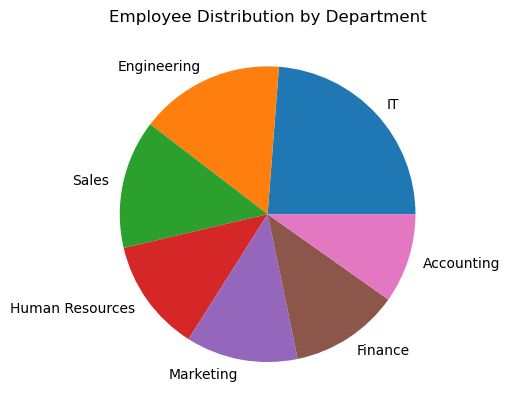

In [21]:
df["Department"].value_counts()
x=df["Department"].value_counts()
plt.pie(x,labels=x.index)
plt.title("Employee Distribution by Department")

In [22]:
df.groupby("Department")["Age"].mean()

Department
Accounting         43.656250
Engineering        45.858065
Finance            45.034188
Human Resources    44.173554
IT                 44.233257
Marketing          43.216667
Sales              43.586957
Name: Age, dtype: float64

In [23]:
df.groupby("Department")["Annual Salary"].mean()

Department
Accounting         123146.947917
Engineering        108490.441935
Finance            123447.470085
Human Resources    117282.607438
IT                  97820.618026
Marketing          129663.033333
Sales              110946.449275
Name: Annual Salary, dtype: float64

<BarContainer object of 7 artists>

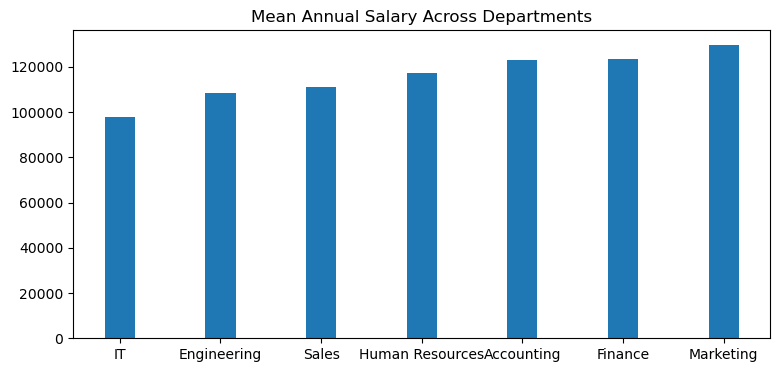

In [24]:
plt.figure(figsize=(9,4))
x=df.groupby("Department")["Annual Salary"].mean().sort_values()
plt.title("Mean Annual Salary Across Departments")
plt.bar(x.index,x,width=0.3)

In [25]:
x=df.groupby(["Department"])["Annual Salary"].max()
print(x)
print("Department",x.idxmax())
print("Value",x.max())


Department
Accounting         258426.0
Engineering        255431.0
Finance            255369.0
Human Resources    250953.0
IT                 256561.0
Marketing          257194.0
Sales              258498.0
Name: Annual Salary, dtype: float64
Department Sales
Value 258498.0


Text(0, 0.5, 'Annual Salary')

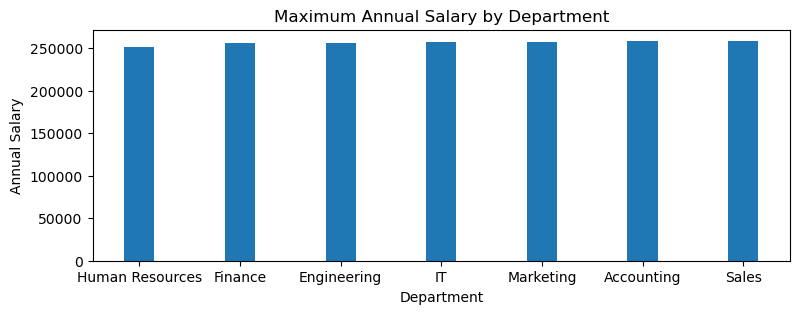

In [26]:
x=df.groupby(["Department"])["Annual Salary"].max().sort_values()
plt.figure(figsize=(9,3))
plt.bar(x.index,x,width=0.3)
plt.title("Maximum Annual Salary by Department")
plt.xlabel("Department")
plt.ylabel("Annual Salary")

In [27]:
y=df.groupby(["Department"])["Annual Salary"].min()
print(y)
print("Department",y.idxmin())
print("Value",y.min())

Department
Accounting         45049.0
Engineering        60017.0
Finance            41336.0
Human Resources    41728.0
IT                 40063.0
Marketing          40752.0
Sales              41429.0
Name: Annual Salary, dtype: float64
Department IT
Value 40063.0


In [28]:
df.groupby("Department")["Bonus %"].mean()

Department
Accounting         0.111354
Engineering        0.071097
Finance            0.113590
Human Resources    0.106198
IT                 0.055150
Marketing          0.124167
Sales              0.083986
Name: Bonus %, dtype: float64

Text(0, 0.5, 'Bonus %')

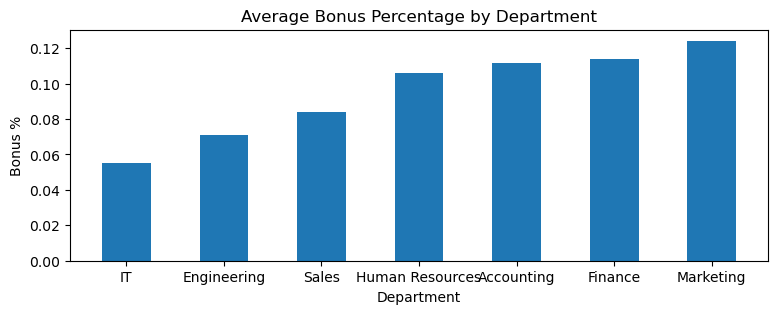

In [29]:
plt.figure(figsize=(9,3))
A=df.groupby("Department")["Bonus %"].mean().sort_values()
plt.bar(A.index,A,width=0.5)
plt.title("Average Bonus Percentage by Department")
plt.xlabel("Department")
plt.ylabel("Bonus %")


In [30]:
df.groupby("Department")["Is Active"].value_counts()

Department       Is Active
Accounting       True          89
                 False          7
Engineering      True         138
                 False         17
Finance          True         108
                 False          9
Human Resources  True         110
                 False         11
IT               True         218
                 False         15
Marketing        True         105
                 False         15
Sales            True         128
                 False         10
Name: count, dtype: int64

In [31]:
df[df["Is Active"]==False]["Department"].value_counts()

Department
Engineering        17
IT                 15
Marketing          15
Human Resources    11
Sales              10
Finance             9
Accounting          7
Name: count, dtype: int64

Text(0.5, 0, 'Department')

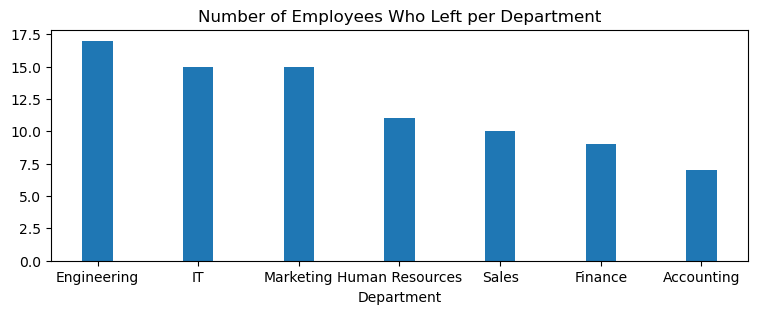

In [32]:
plt.figure(figsize=(9,3))
x=df[df["Is Active"]==False]["Department"].value_counts()
plt.title("Number of Employees Who Left per Department")
plt.bar(x.index,x,width=0.3)
plt.xlabel("Department")


Text(0.5, 1.0, 'Employee Distribution by Ethnicity')

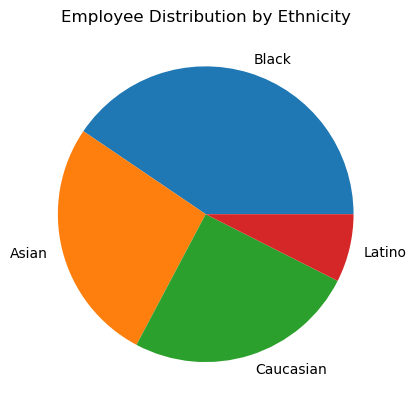

In [33]:
plt.pie(df["Ethnicity"].value_counts(),labels=["Black","Asian","Caucasian","Latino"])
plt.title("Employee Distribution by Ethnicity")

In [34]:
df.groupby(["Department","Ethnicity"])["Age"].max()

Department       Ethnicity
Accounting       Asian        64.0
                 Black        51.0
                 Caucasian    62.0
                 Latino       62.0
Engineering      Asian        65.0
                 Black        56.0
                 Caucasian    64.0
                 Latino       64.0
Finance          Asian        64.0
                 Black        65.0
                 Caucasian    64.0
                 Latino       65.0
Human Resources  Asian        64.0
                 Black        55.0
                 Caucasian    64.0
                 Latino       65.0
IT               Asian        65.0
                 Black        61.0
                 Caucasian    65.0
                 Latino       64.0
Marketing        Asian        65.0
                 Black        65.0
                 Caucasian    65.0
                 Latino       65.0
Sales            Asian        64.0
                 Black        65.0
                 Caucasian    63.0
                 Latino     

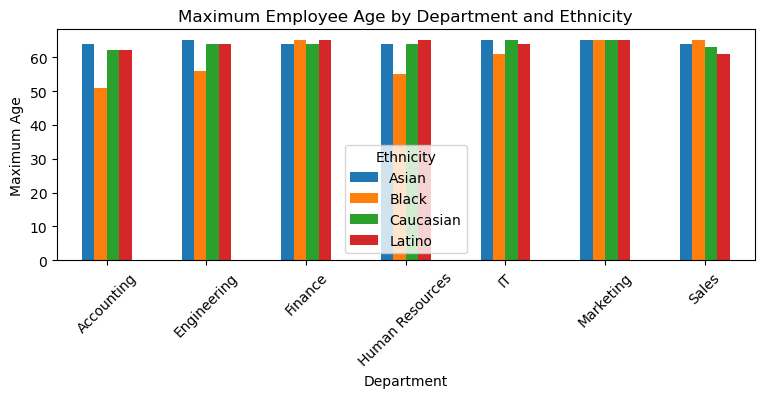

In [35]:
x = df.groupby(["Department", "Ethnicity"])["Age"].max().unstack()

x.plot.bar(figsize=(9,3))
plt.title("Maximum Employee Age by Department and Ethnicity")
plt.ylabel("Maximum Age")
plt.xlabel("Department")
plt.xticks(rotation=45)
plt.show()

In [36]:
df.groupby(["Department","Ethnicity"])["Age"].min()


Department       Ethnicity
Accounting       Asian        25.0
                 Black        30.0
                 Caucasian    26.0
                 Latino       26.0
Engineering      Asian        25.0
                 Black        27.0
                 Caucasian    25.0
                 Latino       27.0
Finance          Asian        25.0
                 Black        25.0
                 Caucasian    25.0
                 Latino       25.0
Human Resources  Asian        25.0
                 Black        25.0
                 Caucasian    26.0
                 Latino       29.0
IT               Asian        25.0
                 Black        28.0
                 Caucasian    26.0
                 Latino       25.0
Marketing        Asian        25.0
                 Black        27.0
                 Caucasian    25.0
                 Latino       29.0
Sales            Asian        25.0
                 Black        26.0
                 Caucasian    26.0
                 Latino     

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'Accounting'),
  Text(1, 0, 'Engineering'),
  Text(2, 0, 'Finance'),
  Text(3, 0, 'Human Resources'),
  Text(4, 0, 'IT'),
  Text(5, 0, 'Marketing'),
  Text(6, 0, 'Sales')])

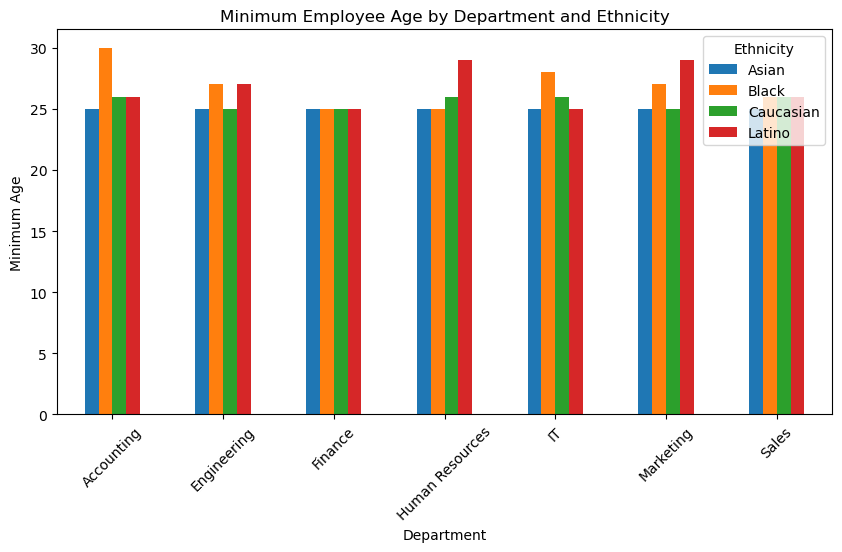

In [37]:
x=df.groupby(["Department","Ethnicity"])["Age"].min().unstack()
x.plot.bar(figsize=(10,5))
plt.title("Minimum Employee Age by Department and Ethnicity")
plt.xlabel("Department")
plt.ylabel("Minimum Age")
plt.xticks(rotation=45)

In [38]:
df.groupby(["Department","Ethnicity"])["Age"].mean()

Department       Ethnicity
Accounting       Asian        45.121951
                 Black        37.333333
                 Caucasian    42.406250
                 Latino       43.600000
Engineering      Asian        46.946429
                 Black        42.142857
                 Caucasian    45.833333
                 Latino       45.180000
Finance          Asian        47.408163
                 Black        48.000000
                 Caucasian    42.407407
                 Latino       42.781250
Human Resources  Asian        43.583333
                 Black        40.307692
                 Caucasian    45.296296
                 Latino       45.636364
IT               Asian        43.766667
                 Black        42.650000
                 Caucasian    45.807731
                 Latino       43.500000
Marketing        Asian        45.400000
                 Black        42.500000
                 Caucasian    40.636364
                 Latino       42.000000
Sales        

In [39]:
df.groupby(["Department","Ethnicity"])["Annual Salary"].median()


Department       Ethnicity
Accounting       Asian        114893.0
                 Black         91853.0
                 Caucasian    121159.5
                 Latino        92317.0
Engineering      Asian         91230.0
                 Black         74412.0
                 Caucasian     93630.0
                 Latino        96818.0
Finance          Asian        124928.0
                 Black        131652.0
                 Caucasian    102847.0
                 Latino       124553.0
Human Resources  Asian        123233.5
                 Black        142318.0
                 Caucasian    104162.0
                 Latino       101985.0
IT               Asian         90652.5
                 Black         74834.5
                 Caucasian     81218.0
                 Latino        83403.0
Marketing        Asian        147752.0
                 Black         86075.5
                 Caucasian    113135.0
                 Latino        97063.5
Sales            Asian         89528.

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'Accounting'),
  Text(1, 0, 'Engineering'),
  Text(2, 0, 'Finance'),
  Text(3, 0, 'Human Resources'),
  Text(4, 0, 'IT'),
  Text(5, 0, 'Marketing'),
  Text(6, 0, 'Sales')])

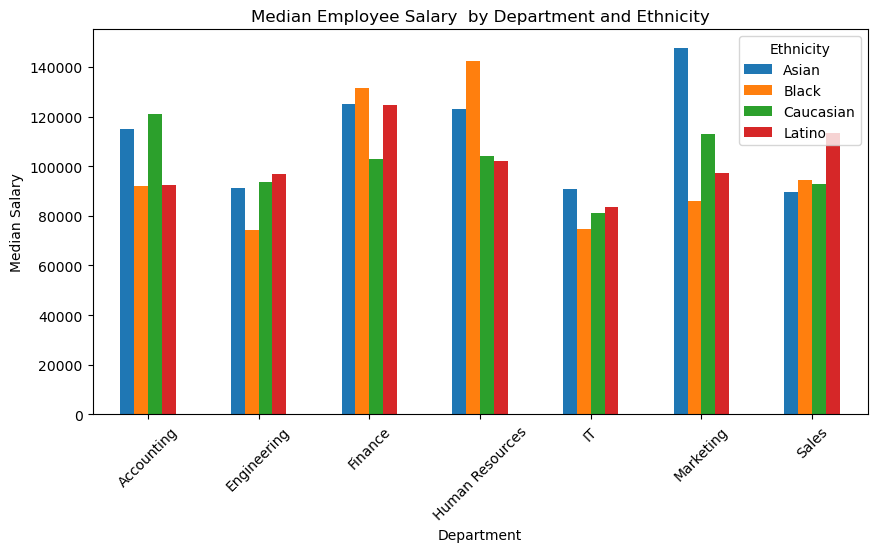

In [40]:
x=df.groupby(["Department","Ethnicity"])["Annual Salary"].median().unstack()
x.plot.bar(figsize=(10,5))
plt.title("Median Employee Salary  by Department and Ethnicity")
plt.xlabel("Department")
plt.ylabel("Median Salary")
plt.xticks(rotation=45)

In [41]:
df.to_excel(r"C:\Users\MT-Team\Desktop\Employee Analysis\Employee Sample Data_clean - A.xlsx")

In [42]:
df["Age Group"] = pd.cut(df["Age"], bins=[0,20,30,40,50,60,70])
df["Age Group"].value_counts()

Age Group
(40, 50]    277
(50, 60]    236
(30, 40]    231
(20, 30]    148
(60, 70]     88
(0, 20]       0
Name: count, dtype: int64

Text(0.5, 1.0, 'Employee Distribution by Age Group')

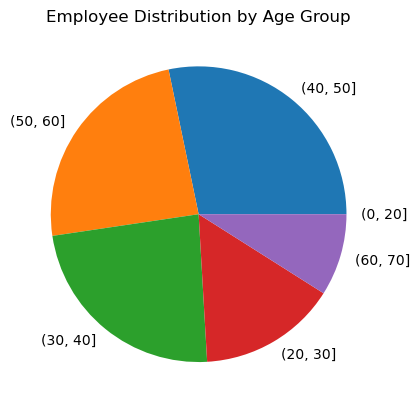

In [43]:
plt.pie(df["Age Group"].value_counts(),labels=(df["Age Group"].value_counts().index))
plt.title("Employee Distribution by Age Group")

In [44]:
df.groupby(["Age"])["Annual Salary"].median()

Age
25.000000    120263.0
26.000000     74467.0
27.000000    123681.0
28.000000     92674.5
29.000000    122054.0
30.000000     90296.0
31.000000    100620.0
32.000000    100722.5
33.000000     94876.0
34.000000     94735.0
35.000000     76859.5
36.000000     97128.5
37.000000    103524.0
38.000000    108335.0
39.000000     90535.0
40.000000     93971.0
41.000000    128426.5
42.000000     99697.0
43.000000    105762.0
44.000000    101871.5
44.348884     92952.0
45.000000     97456.0
46.000000     96639.0
47.000000     92897.0
48.000000     93017.0
49.000000    122241.5
50.000000    106432.5
51.000000     98287.0
52.000000    113766.5
53.000000    101673.5
54.000000     95840.0
55.000000     94376.0
56.000000     77605.0
57.000000     95061.0
58.000000     76354.0
59.000000    101985.0
60.000000    106578.0
61.000000     88478.0
62.000000     80921.0
63.000000    122487.0
64.000000    109118.0
65.000000     83756.0
Name: Annual Salary, dtype: float64

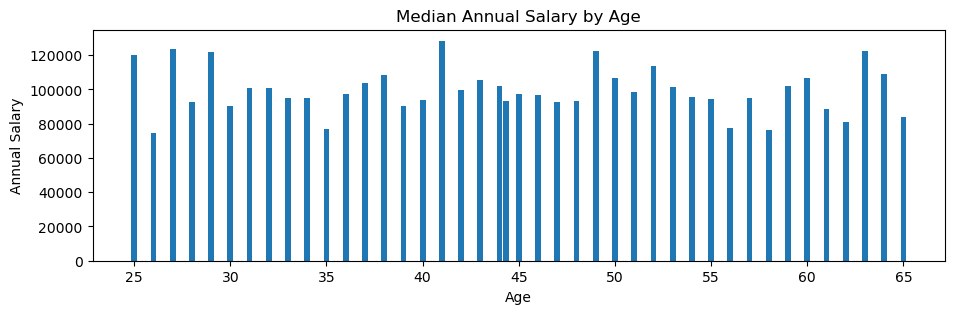

In [45]:
plt.figure(figsize=(11,3))
x=df.groupby(["Age"])["Annual Salary"].median()

plt.bar(x.index,x,width=0.3)
plt.title("Median Annual Salary by Age")
plt.xlabel("Age")
plt.ylabel("Annual Salary")
plt.show()

In [46]:
x=df.groupby(["Age"])["Annual Salary"].max()
print(x)
print("Age",x.idxmax())
print("value",x.max())

Age
25.000000    210708.0
26.000000    256561.0
27.000000    256420.0
28.000000    250767.0
29.000000    199783.0
30.000000    255431.0
31.000000    250953.0
32.000000    203445.0
33.000000    258426.0
34.000000    220937.0
35.000000    245482.0
36.000000    253294.0
37.000000    225558.0
38.000000    255230.0
39.000000    254057.0
40.000000    242919.0
41.000000    257194.0
42.000000    186725.0
43.000000    258498.0
44.000000    207172.0
44.348884     92952.0
45.000000    249801.0
46.000000    173629.0
47.000000    253249.0
48.000000    258081.0
49.000000    211291.0
50.000000    247939.0
51.000000    247874.0
52.000000    236314.0
53.000000    198473.0
54.000000    247022.0
55.000000    221465.0
56.000000    228822.0
57.000000    246589.0
58.000000    199848.0
59.000000    246619.0
60.000000    234311.0
61.000000    201464.0
62.000000    234594.0
63.000000    254289.0
64.000000    252325.0
65.000000    175837.0
Name: Annual Salary, dtype: float64
Age 43.0
value 258498.0


In [47]:
x=df.groupby(["Age"])["Annual Salary"].min()
print("Age",x.idxmin())
print("value",x.min())

Age 61.0
value 40063.0


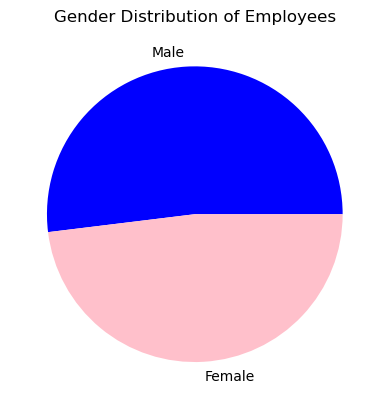

In [48]:
plt.pie(df["Gender"].value_counts(),labels=["Male","Female"],colors=["blue","pink"])
plt.title("Gender Distribution of Employees")
plt.show()

In [49]:
df[df["Gender"]=="Female"]["Department"].value_counts()

Department
IT                 116
Engineering         80
Sales               74
Finance             67
Human Resources     62
Marketing           57
Accounting          53
Name: count, dtype: int64

Text(0, 0.5, 'Number of Female')

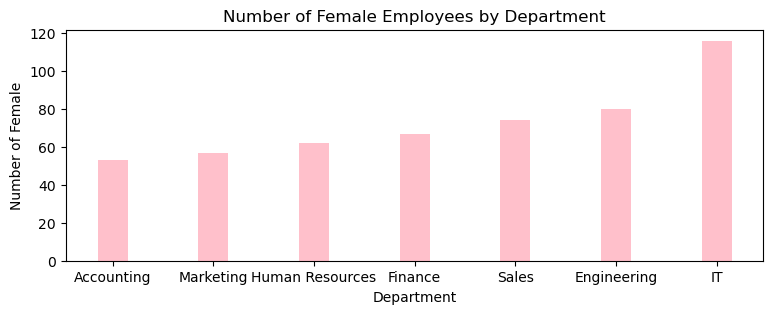

In [50]:
plt.figure(figsize=(9,3))
B=df[df["Gender"]=="Female"]["Department"].value_counts().sort_values()
plt.bar(B.index,B,width=0.3,color="pink")
plt.title("Number of Female Employees by Department")
plt.xlabel("Department")
plt.ylabel("Number of Female")

In [51]:
df.groupby("Gender")["Annual Salary"].mean()

Gender
Female    112421.063851
Male      114039.769639
Name: Annual Salary, dtype: float64

([<matplotlib.patches.Wedge at 0x27355bc9100>,
 [Text(-0.12316086523257733, 1.0930834374717984, 'Male'),
  Text(0.12316076289071877, -1.0930834490029462, 'Female')])

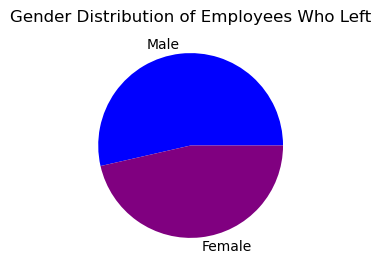

In [52]:
plt.figure(figsize=(9,3))
x=df[df["Is Active"]==False]["Gender"].value_counts()
plt.title("Gender Distribution of Employees Who Left")
plt.pie(x,labels=x.index,colors=("blue","purple"))

Text(0.5, 0, 'Gender')

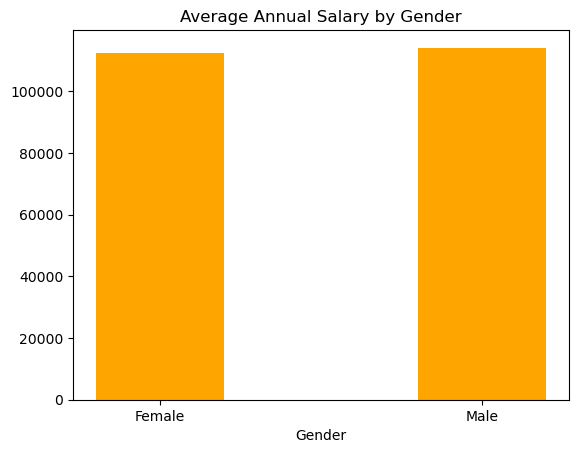

In [53]:
x=df.groupby("Gender")["Annual Salary"].mean()
plt.bar(x.index,x,width=0.4,color="orange")
plt.title("Average Annual Salary by Gender")
plt.xlabel("Gender")

Text(0.5, 1.0, 'Distribution of Active and Inactive Employees')

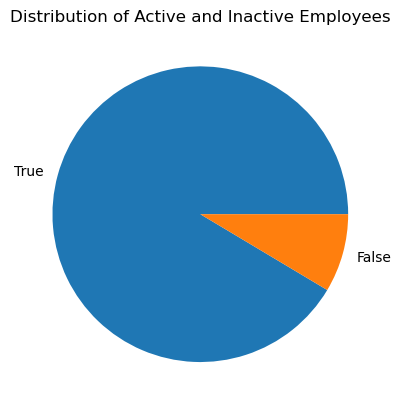

In [54]:
x=df["Is Active"].value_counts()
plt.pie(x,labels=x.index)
plt.title("Distribution of Active and Inactive Employees")

([<matplotlib.patches.Wedge at 0x27353c4f170>,
 [Text(-0.12316086523257733, 1.0930834374717984, 'Male'),
  Text(0.12316076289071877, -1.0930834490029462, 'Female')])

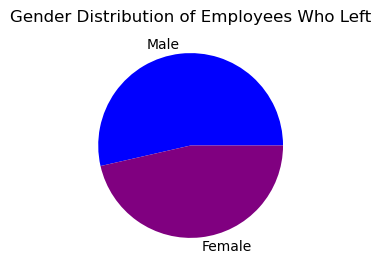

In [55]:
plt.figure(figsize=(9,3))
x=df[df["Is Active"]==False]["Gender"].value_counts()
plt.title("Gender Distribution of Employees Who Left")
plt.pie(x,labels=x.index,colors=("blue","purple"))

Text(0.5, 1.0, 'Employee Distribution by Country')

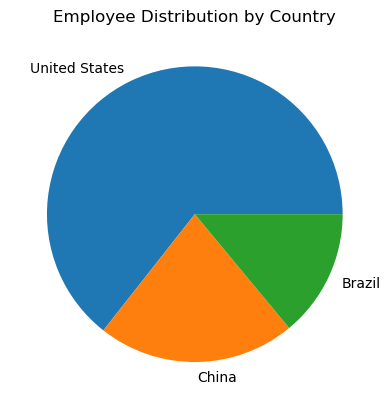

In [56]:
x=df["Country"].value_counts()

plt.pie(x,labels=x.index)
plt.title("Employee Distribution by Country")

Text(0.5, 1.0, 'Employee Distribution by City')

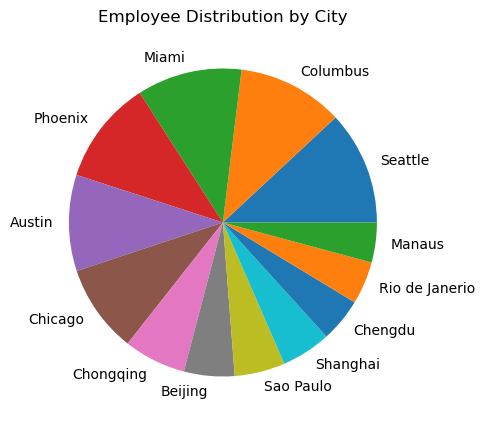

In [57]:
plt.figure(figsize=(11,5))
y=df["City"].value_counts()

plt.pie(y,labels=y.index)
plt.title("Employee Distribution by City")

In [58]:
df.groupby(["Country","City"])["Is Active"].mean()

Country        City          
Brazil         Manaus            0.878049
               Rio de Janerio    0.954545
               Sao Paulo         0.923077
China          Beijing           0.884615
               Chengdu           0.911111
               Chongqing         0.890625
               Shanghai          0.921569
United States  Austin            0.888889
               Chicago           0.923077
               Columbus          0.917431
               Miami             0.888889
               Phoenix           0.953271
               Seattle           0.931624
Name: Is Active, dtype: float64

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]),
 [Text(0, 0, '(Brazil, Manaus)'),
  Text(1, 0, '(Brazil, Rio de Janerio)'),
  Text(2, 0, '(Brazil, Sao Paulo)'),
  Text(3, 0, '(China, Beijing)'),
  Text(4, 0, '(China, Chengdu)'),
  Text(5, 0, '(China, Chongqing)'),
  Text(6, 0, '(China, Shanghai)'),
  Text(7, 0, '(United States, Austin)'),
  Text(8, 0, '(United States, Chicago)'),
  Text(9, 0, '(United States, Columbus)'),
  Text(10, 0, '(United States, Miami)'),
  Text(11, 0, '(United States, Phoenix)'),
  Text(12, 0, '(United States, Seattle)')])

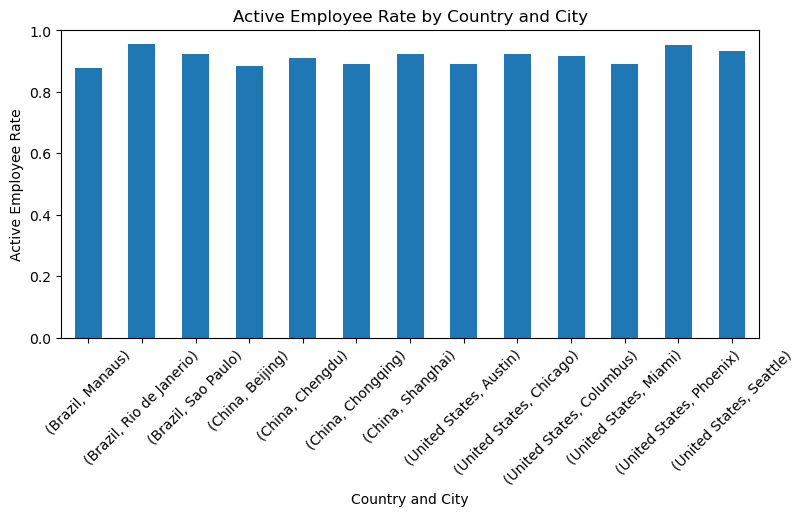

In [59]:
x=df.groupby(["Country","City"])["Is Active"].mean()
x.plot.bar(figsize=(9,4))
plt.title("Active Employee Rate by Country and City")
plt.xlabel("Country and City")
plt.ylabel("Active Employee Rate")
plt.xticks(rotation=45)


In [60]:
df.groupby(["Country","City"])["Annual Salary"].mean()

Country        City          
Brazil         Manaus            116137.560976
               Rio de Janerio    108275.931818
               Sao Paulo         114227.942308
China          Beijing           108569.576923
               Chengdu           111183.711111
               Chongqing         115270.875000
               Shanghai          119447.117647
United States  Austin            116000.767677
               Chicago           111502.609890
               Columbus          114441.981651
               Miami             113741.481481
               Phoenix           108034.579439
               Seattle           114552.354701
Name: Annual Salary, dtype: float64

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]),
 [Text(0, 0, '(United States, Phoenix)'),
  Text(1, 0, '(Brazil, Rio de Janerio)'),
  Text(2, 0, '(China, Beijing)'),
  Text(3, 0, '(China, Chengdu)'),
  Text(4, 0, '(United States, Chicago)'),
  Text(5, 0, '(United States, Miami)'),
  Text(6, 0, '(Brazil, Sao Paulo)'),
  Text(7, 0, '(United States, Columbus)'),
  Text(8, 0, '(United States, Seattle)'),
  Text(9, 0, '(China, Chongqing)'),
  Text(10, 0, '(United States, Austin)'),
  Text(11, 0, '(Brazil, Manaus)'),
  Text(12, 0, '(China, Shanghai)')])

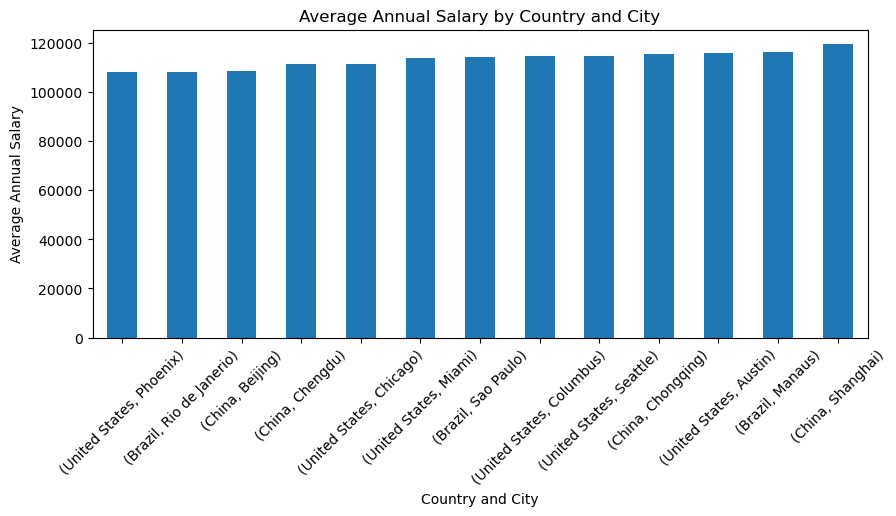

In [61]:
x=df.groupby(["Country","City"])["Annual Salary"].mean().sort_values()
x.plot.bar(figsize=(10,4))
plt.title("Average Annual Salary by Country and City")
plt.xlabel("Country and City")
plt.ylabel("Average Annual Salary")
plt.xticks(rotation=45)


In [62]:

df["Job Title"].value_counts()

Job Title
Director                          119
Sr. Manger                        107
Vice President                    103
Manager                            97
Sr. Analyst                        68
Analyst II                         52
Analyst                            51
Computer Systems Manager           21
Account Representative             21
Engineering Manager                20
Quality Engineer                   20
Development Engineer               19
Field Engineer                     19
Business Partner                   18
Network Architect                  17
Enterprise Architect               17
Sr. Business Partner               17
HRIS Analyst                       16
Technical Architect                16
Cloud Infrastructure Architect     15
Controls Engineer                  15
Systems Analyst                    15
System Administrator               14
Solutions Architect                14
Operations Engineer                12
Test Engineer                      12
IT

In [63]:
df["Business Unit"].value_counts()
	

Business Unit
Manufacturing             262
Speciality Products       261
Corporate                 232
Research & Development    225
Name: count, dtype: int64

Text(0.5, 1.0, ' Distribution by Business Unit')

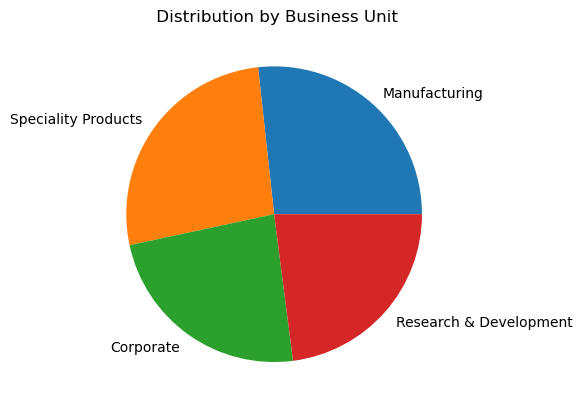

In [64]:
x=df["Business Unit"].value_counts()
plt.pie(x,labels=x.index)
plt.title(" Distribution by Business Unit")

In [65]:
df.groupby("Business Unit")["Annual Salary"].mean()

Business Unit
Corporate                 119442.125000
Manufacturing             103988.648855
Research & Development    112667.871111
Speciality Products       117353.191571
Name: Annual Salary, dtype: float64

Text(0.5, 1.0, 'Average Annual Salary by Business Unit')

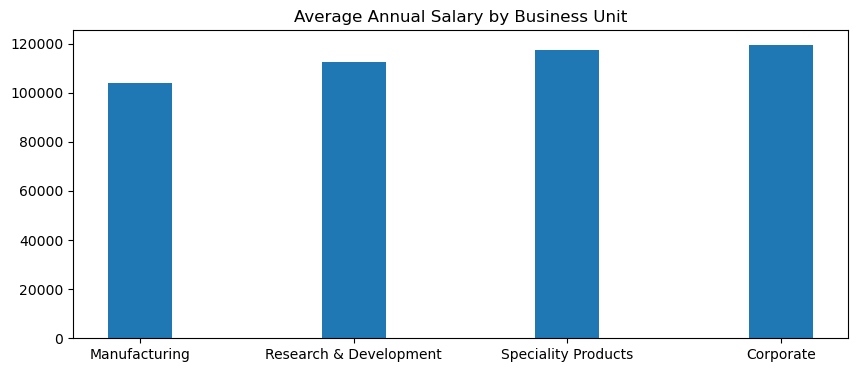

In [66]:
x=df.groupby("Business Unit")["Annual Salary"].mean().sort_values()
plt.figure(figsize=(10,4))
plt.bar(x.index,x,width=0.3)
plt.title("Average Annual Salary by Business Unit")

In [135]:
df[["Annual Salary", "Bonus %", "Age"]].corr()	

,Annual Salary,Bonus %,Age
Annual Salary,1.000000,0.925655,-0.025489
Bonus %,0.925655,1.000000,-0.017435
Age,-0.025489,-0.017435,1.000000


There is a strong positive correlation between salary and bonus (0.92), which indicates that employees with higher salaries tend to receive higher bonuses.
There is no meaningful relationship between bonus and age, as the correlation is very close to zero.
There is no significant relationship between salary and age, as the correlation is very weak and close to zero.

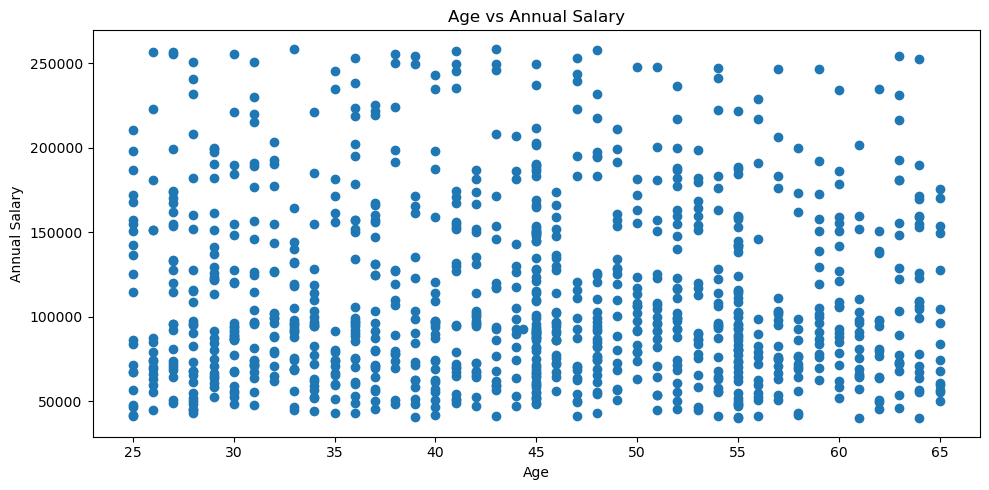

In [146]:
plt.figure(figsize=(10,5))
plt.scatter(df["Age"], df["Annual Salary"])
plt.title("Age vs Annual Salary")
plt.xlabel("Age")
plt.ylabel("Annual Salary")
plt.tight_layout()
plt.show()

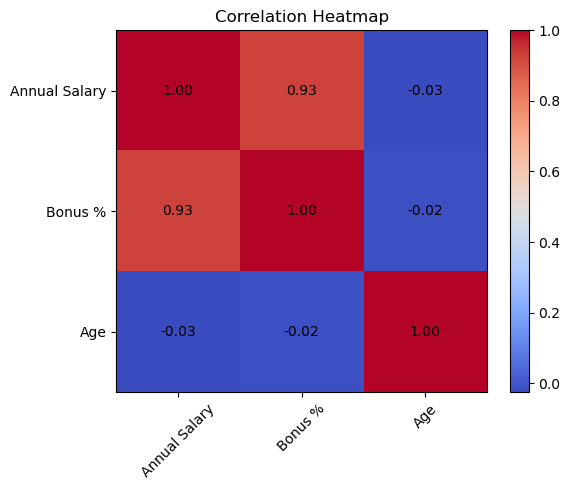

In [156]:


corr = df[["Annual Salary", "Bonus %", "Age"]].corr()

plt.figure(figsize=(6,5))
plt.imshow(corr, cmap="coolwarm", interpolation="none", aspect="auto")
plt.colorbar()


plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)


for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

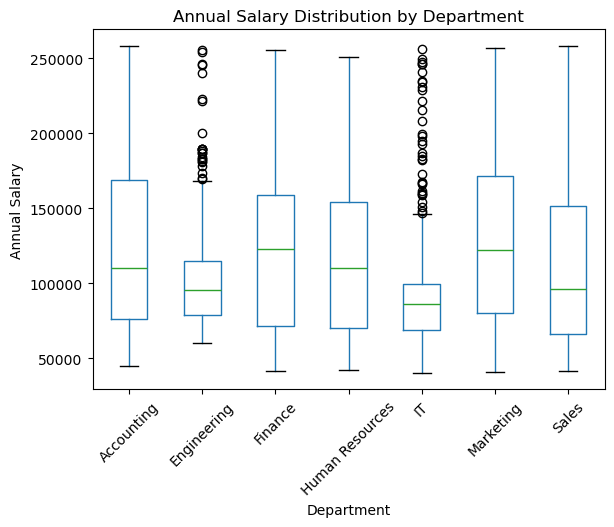

In [151]:

plt.figure(figsize=(10,6))
df.boxplot(column="Annual Salary", by="Department", grid=False)

plt.title("Annual Salary Distribution by Department")
plt.suptitle("")  # removes automatic extra title
plt.xlabel("Department")
plt.ylabel("Annual Salary")
plt.xticks(rotation=45)
#plt.tight_layout()
plt.show()

 Marketing & Finan:Higher median salaries (~120k) hese departments are higher paying
 IT:lower median BUT many outliers:Some employees earn very high salaries (senior roles)
 Engineering:Medium median (~95k)butMany outliers:ig salary gap between junior and senior
 A boxplot visualization was used to effectively highlight salary distribution, variability, and outliers across departments.

df.to_excel(r"C:\Users\MT-Team\Desktop\Training\Employee Sample Data_clean - A.xlsx")